In [ ]:
from random import randint
from typing import TypedDict,Literal,Sequence

from anthropic.types.beta import messages
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langchain.messages import HumanMessage
from dotenv import load_dotenv
from langchain.tools import tool
from sympy.codegen.cnodes import goto
from rich import print as rprint
import os
from langchain.chat_models import init_chat_model
load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-3.1-flash-lite",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

# 使用代码函数模拟代替外部API调用的天气查询
@tool(parse_docstring=True)
def get_weather(city:str = "上海"):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city}的天气是晴朗的"

@tool(parse_docstring=True)
def get_news(domain:Literal["AI","食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
       return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    elif domain == "食品安全":
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"
    else:
        return "未知的新闻领域"

# 绑定工具到模型
tools = [get_weather,get_news]
model_with_tool = model.bind_tools(tools=tools)

res = model_with_tool.invoke(input="查询今天上海的天气和AI新闻")
rprint(res)


AIMessage(
    content=[],
    additional_kwargs={
        'function_call': {'name': 'get_news', 'arguments': '{"domain": "AI"}'},
        '__gemini_function_call_thought_signatures__': {
            '442c9faf-d5c7-47ef-8dca-e34edafa98f9': 
'EnEKbwERTTIPBXXKdOjxTGAJpD0TNey8Zjtg1JWeBtsdivteQu+pjJWsXLePx/pdvK3pu9YxFF3SgHkwhoDDPvWwSa05T5SNpXFXWYlHorEwC6cuXZ
MuuRT8trXGtnJtJtd3iS54eSYyJfud2UHEglDjAg=='
        }
    },
    response_metadata={
        'prompt_feedback': {'block_reason': 0, 'safety_ratings': []},
        'finish_reason': 'STOP',
        'model_name': 'gemini-3.1-flash-lite',
        'safety_ratings': [],
        'model_provider': 'google_genai'
    },
    id='lc_run--019ff62f-e3d1-7b31-aa7d-4c0d689efaf5-0',
    tool_calls=[
        {
            'name': 'get_weather',
            'args': {'city': '上海'},
            'id': '442c9faf-d5c7-47ef-8dca-e34edafa98f9',
            'type': 'tool_call'
        },
        {
            'name': 'get_news',
            'args': {'domain': 'AI'},
            'id': '674d1c75-f7e1-432d-921b-49d8d6d421ba',
            'type': 'tool_call'
        }
    ],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 113,
        'output_tokens': 32,
        'total_tokens': 145,
        'input_token_details': {'cache_read': 0}
    }
)

NameError: name 'graph' is not defined

user_input: 查询今天的上海天气和AI新闻热点
final_output: [{'type': 'text', 'text': '今天上海的天气是晴朗的。\n\n关于今日的AI领域热点：Anthropic 发布了 Claude Opus-4.8，但有用户发现，通过 API 使用中文询问“你是谁？”时，它在大多数情况下会错误地回答自己是“Qwen”或“Deepseek”。', 'extras': {'signature': 'EnEKbwERTTIPcAmWbor6VGEvkdZlrk4qUQHl1BmyHg2fJFK2eTNwAf5Y6+Q15dkUCdL/dMM0rXD1cWtp/XmpMGkkTnIVUSvuDd98XcnnHouuJkLtn+vy5D0GUfJXUb62cRN1lOV1Cq3kuti7IZ3Y3bFqBg=='}}]
================================ System Message ================================

如果工具调用失败,必须重新调用直到成功为止
================================ Human Message =================================

查询今天的上海天气和AI新闻热点
================================== Ai Message ==================================

[]
Tool Calls:
  get_weather (21856c30-be8c-4e02-bbb4-b0fc2386e116)
 Call ID: 21856c30-be8c-4e02-bbb4-b0fc2386e116
  Args:
    city: 上海
  get_news (ca1a7567-78ac-4d45-8c95-38613eaf4cd3)
 Call ID: ca1a7567-78ac-4d45-8c95-38613eaf4cd3
  Args:
    domain: AI
================================= Tool Message ================================

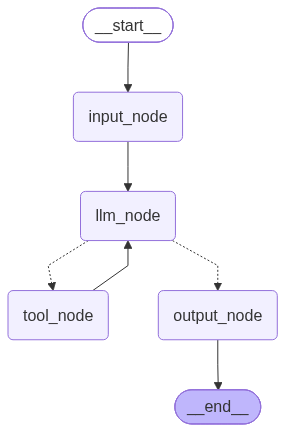

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	input_node(input_node)
	llm_node(llm_node)
	tool_node(tool_node)
	output_node(output_node)
	__end__([<p>__end__</p>]):::last
	__start__ --> input_node;
	input_node --> llm_node;
	llm_node -.-> output_node;
	llm_node -.-> tool_node;
	tool_node --> llm_node;
	output_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [5]:
#1. 声明状态
class OverAllState(MessagesState):
    user_input:str
    final_output:str

#2. 声明节点
#2.1 输入节点 => 将用户输入的查询信息  记录到message中 方便后续的大模型调用
def input_node(state:OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])]
    }

#2.2 大模型节点
def llm_node(state:OverAllState) -> Command[Literal["tool_node","output_node"]]:
    # 使用goto方式完成动态调用循环结构
    ai_msg = model_with_tool.invoke(state["messages"])
    #判断接下来需要调用的节点
    if ai_msg.tool_calls:
        goto = "tool_node"
    else:
        goto = "output_node"
    return Command(
        update={
            "messages" : [ai_msg]
        },
        goto=goto
    )


#2.3 判断是否需要调用工具
def tool_node(state:OverAllState) -> OverAllState:
    # 判断大模型的返回信息 是否需要调用tool
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    # 6表示函数调用60%失败
    fail_prob = 6

    for tool_call in tool_calls:
        if tool_call["name"]== "get_weather":
            # 生成[0-9]数字 判断大小
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动,调用失败,请重试",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动,调用失败,请重试",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(ToolMessage(
                content="工具名称错误,调用失败,请重试",
                 tool_call_id = tool_call["id"]
                 ))
    return {
        "messages":messages
    }


#2.4 返回输出节点
def output_node(state:OverAllState) -> OverAllState:
    return {
        "final_output":state["messages"][-1].content
    }



#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node",input_node)
builder.add_node("llm_node",llm_node)
builder.add_node("tool_node",tool_node)
builder.add_node("output_node",output_node)

builder.add_edge(START,"input_node")
builder.add_edge("input_node","llm_node")
builder.add_edge("tool_node","llm_node")
builder.add_edge("output_node",END)

graph = builder.compile()

ai_res = graph.invoke({
    "user_input":"查询今天的上海天气和AI新闻热点",
    "messages":[SystemMessage("如果工具调用失败,必须重新调用直到成功为止")]
})

print("user_input:",ai_res["user_input"])
print("final_output:",ai_res["final_output"])
for msg in ai_res["messages"]:
    msg.pretty_print()

from IPython.display import  display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)